<a href="https://colab.research.google.com/github/letruc271193-dot/btvn/blob/main/nhandienface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/anhai/Ảnh selfie cho chiều t2 18 5"

# Kích thước ảnh và kích thước lô
img_width, img_height = 200,200
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 2307 images belonging to 42 classes.


In [3]:
# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(42, activation="softmax") # 5 categories
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │         5,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,765,930 (33.44 MB)

 Trainable params: 8,765,930 (33.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 1741s 24s/step - accuracy: 0.0867 - loss: 3.5558
Epoch 2/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 36s 492ms/step - accuracy: 0.1951 - loss: 3.0686
Epoch 3/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 35s 475ms/step - accuracy: 0.2739 - loss: 2.6918
Epoch 4/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 36s 498ms/step - accuracy: 0.3433 - loss: 2.4390
Epoch 5/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 35s 479ms/step - accuracy: 0.4222 - loss: 2.1345
Epoch 6/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 503ms/step - accuracy: 0.4855 - loss: 1.9165
Epoch 7/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 35s 479ms/step - accuracy: 0.5457 - loss: 1.6884
Epoch 8/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 36s 494ms/step - accuracy: 0.5730 - loss: 1.5034
Epoch 9/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.6246 - loss: 1.3317
Epoch 10/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 499ms/step - accuracy: 0.6316 - loss: 1.3263
Epoch 11/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 35s 473ms/step - accuracy: 0.6623 - loss: 1.2319
Epoch 12/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 36

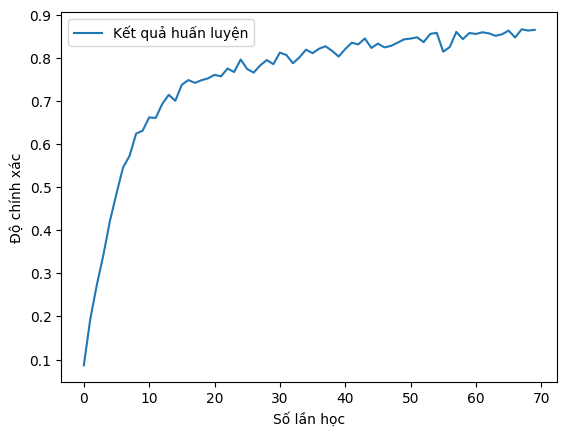

In [4]:
# Biên dịch mô hình
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 70
history = model.fit(train_generator, epochs=epochs)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
# Kiểm tra nếu có dữ liệu xác thực mới vẽ để tránh lỗi KeyError
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

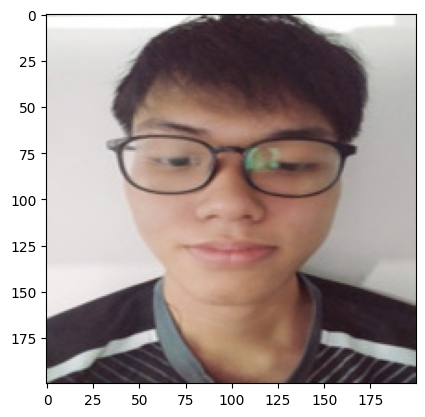

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Người tiên đoán: Lê Minh Huy


In [7]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import numpy as np
path = "/content/anh1.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(200,200))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 200,200, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")